In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
import sys
print(sys.executable)

C:\Users\anjal\AppData\Local\Programs\Python\Python314\python.exe


In [3]:

sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:

trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print("Fear & Greed Dataset Shape:", sentiment.shape)
print("Historical Trader Dataset Shape:", trader.shape)

Fear & Greed Dataset Shape: (2644, 4)
Historical Trader Dataset Shape: (211224, 16)


In [6]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 127.5 KB


In [7]:
trader.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [8]:
print("Missing values in Fear & Greed Dataset:")
print(sentiment.isnull().sum())

print("\nMissing values in Historical Dataset:")
print(trader.isnull().sum())

Missing values in Fear & Greed Dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Historical Dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [9]:
print("Duplicate rows in Fear & Greed Dataset:", sentiment.duplicated().sum())
print("Duplicate rows in Historical Dataset:", trader.duplicated().sum())

Duplicate rows in Fear & Greed Dataset: 0
Duplicate rows in Historical Dataset: 0


In [10]:

print("Missing Values in Sentiment Dataset")
print(sentiment.isnull().sum())

print("\nMissing Values in Trader Dataset")
print(trader.isnull().sum())

Missing Values in Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [11]:

print("Duplicate rows in Sentiment Dataset:", sentiment.duplicated().sum())
print("Duplicate rows in Trader Dataset:", trader.duplicated().sum())

Duplicate rows in Sentiment Dataset: 0
Duplicate rows in Trader Dataset: 0


In [12]:
sentiment = sentiment.drop_duplicates()
trader = trader.drop_duplicates()

In [13]:

sentiment["date"] = pd.to_datetime(sentiment["date"])

trader["Timestamp IST"] = pd.to_datetime(
    trader["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [14]:

trader["date"] = trader["Timestamp IST"].dt.date

In [15]:
trader["date"] = pd.to_datetime(trader["date"])

In [16]:
print(sentiment.info())

print(trader.info())

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   str           
 3   date            2644 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 101.7 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-nu

In [17]:
print("Sentiment Date Range")
print(sentiment["date"].min())
print(sentiment["date"].max())

print("\nTrader Date Range")
print(trader["date"].min())
print(trader["date"].max())

Sentiment Date Range
2018-02-01 00:00:00
2025-05-02 00:00:00

Trader Date Range
2023-05-01 00:00:00
2025-05-01 00:00:00


In [18]:
# Merge trader data with sentiment data

merged = pd.merge(
    trader,
    sentiment,
    on="date",
    how="left"
)

In [19]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [20]:
print("Merged Dataset Shape :", merged.shape)

Merged Dataset Shape : (211224, 20)


In [21]:
merged.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
timestamp           6
value               6
classification      6
dtype: int64

In [22]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [23]:


merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

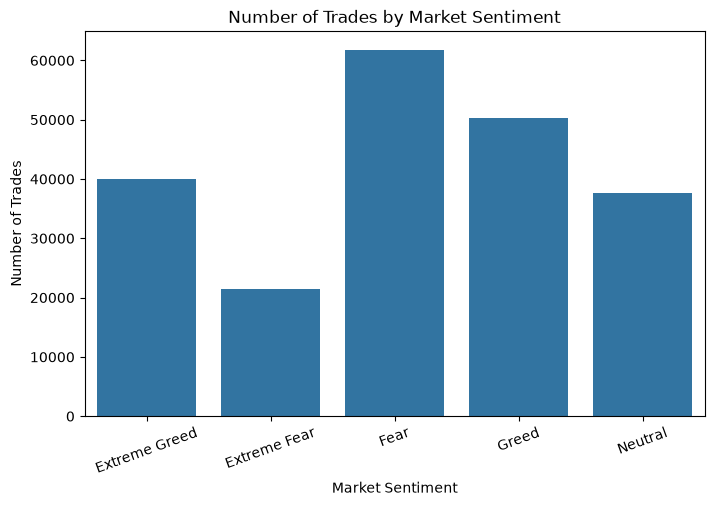

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=merged, x="classification")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=20)

plt.show()

In [25]:

avg_pnl = merged.groupby("classification")["Closed PnL"].mean()

print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


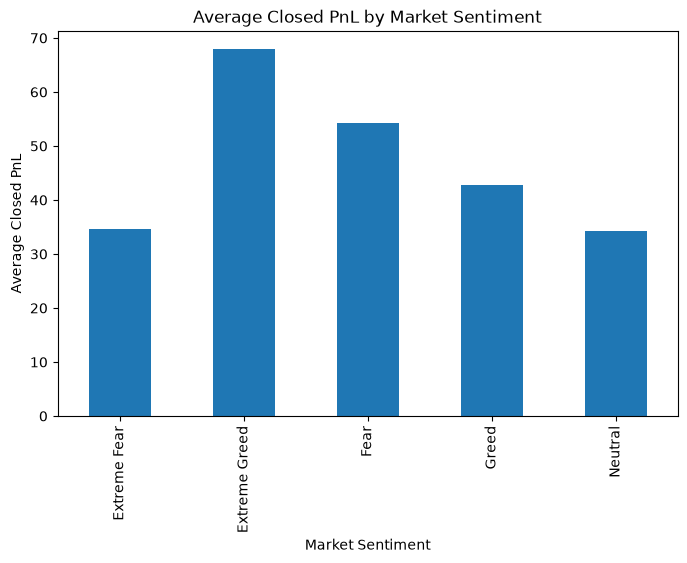

In [26]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

In [27]:
total_pnl = merged.groupby("classification")["Closed PnL"].sum()

print(total_pnl)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


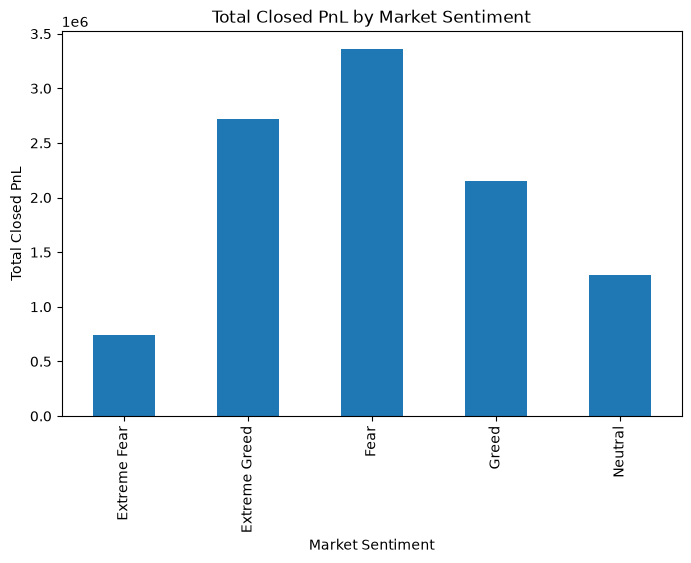

In [28]:
plt.figure(figsize=(8,5))

total_pnl.plot(kind="bar")

plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")

plt.show()

In [29]:
merged["Side"].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

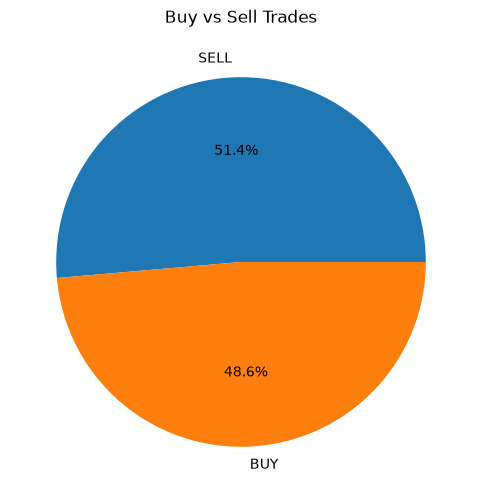

In [30]:
plt.figure(figsize=(6,6))

merged["Side"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Buy vs Sell Trades")

plt.ylabel("")

plt.show()

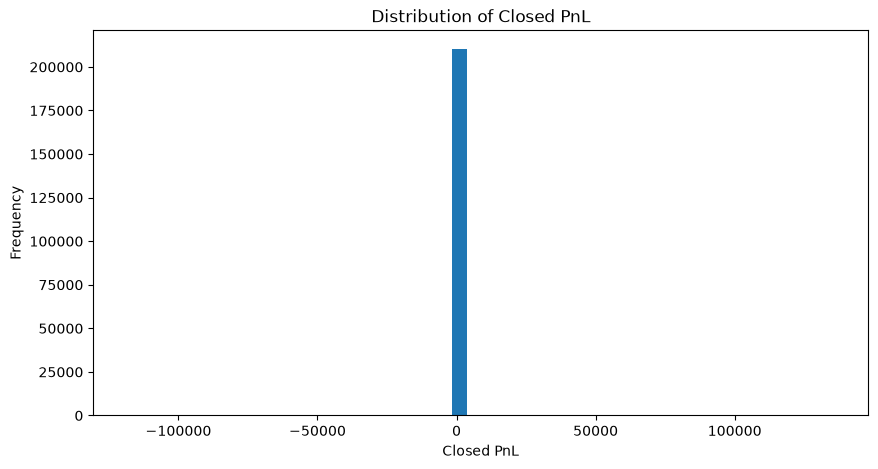

In [31]:
plt.figure(figsize=(10,5))

plt.hist(merged["Closed PnL"], bins=50)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

In [32]:
merged["Coin"].value_counts().head(10)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

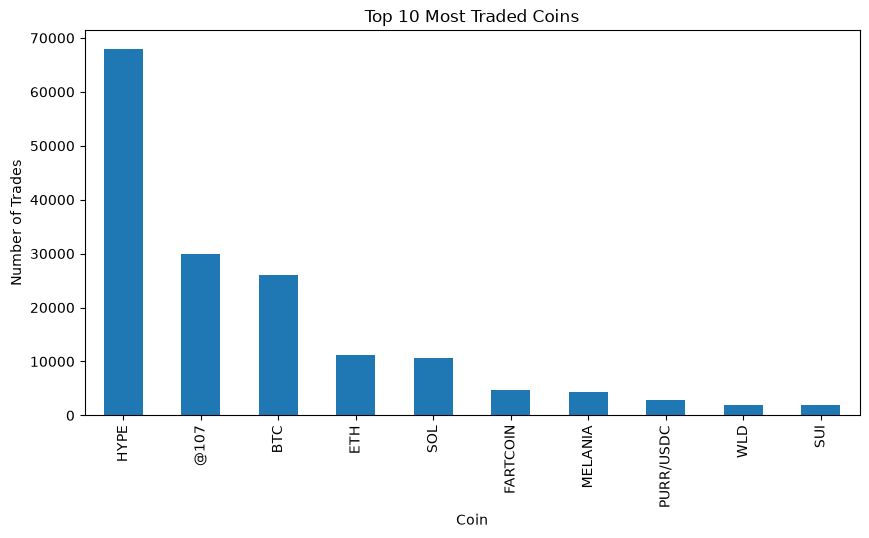

In [33]:
plt.figure(figsize=(10,5))

merged["Coin"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Traded Coins")

plt.xlabel("Coin")

plt.ylabel("Number of Trades")

plt.show()

In [34]:
trade_frequency = merged.groupby("classification").size()

print(trade_frequency)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


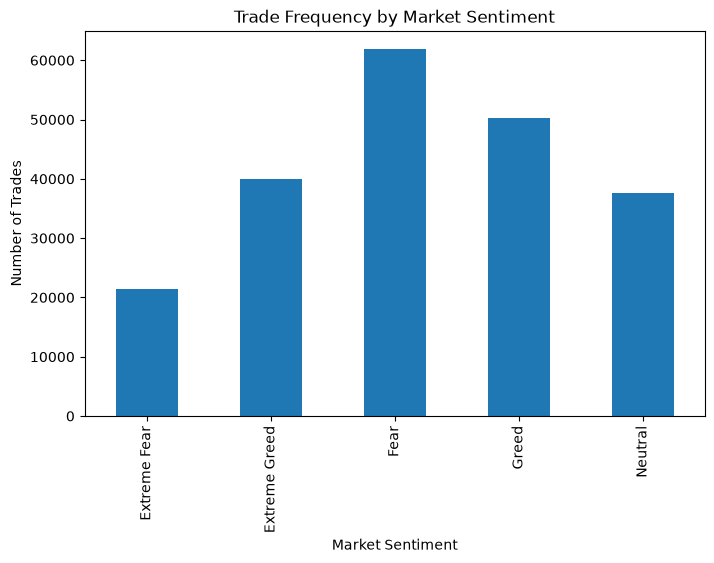

In [35]:
plt.figure(figsize=(8,5))

trade_frequency.plot(kind="bar")

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [36]:
avg_size = merged.groupby("classification")["Size USD"].mean()

print(avg_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


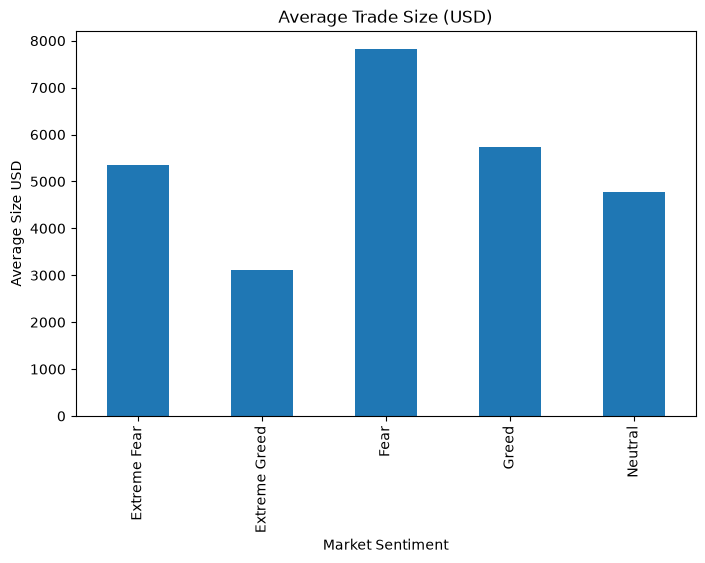

In [37]:
plt.figure(figsize=(8,5))

avg_size.plot(kind="bar")

plt.title("Average Trade Size (USD)")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Size USD")

plt.show()

In [38]:
avg_fee = merged.groupby("classification")["Fee"].mean()

print(avg_fee)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


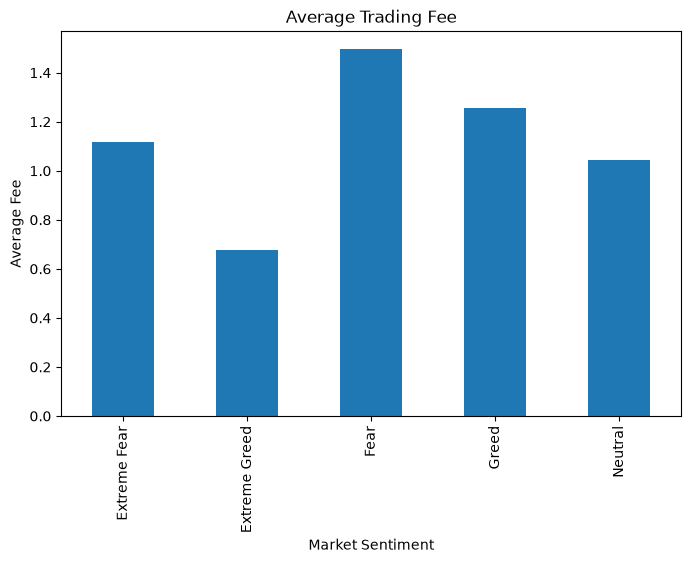

In [39]:
plt.figure(figsize=(8,5))

avg_fee.plot(kind="bar")

plt.title("Average Trading Fee")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Fee")

plt.show()

In [40]:
merged["Win"] = merged["Closed PnL"] > 0

In [41]:
win_rate = merged.groupby("classification")["Win"].mean()*100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


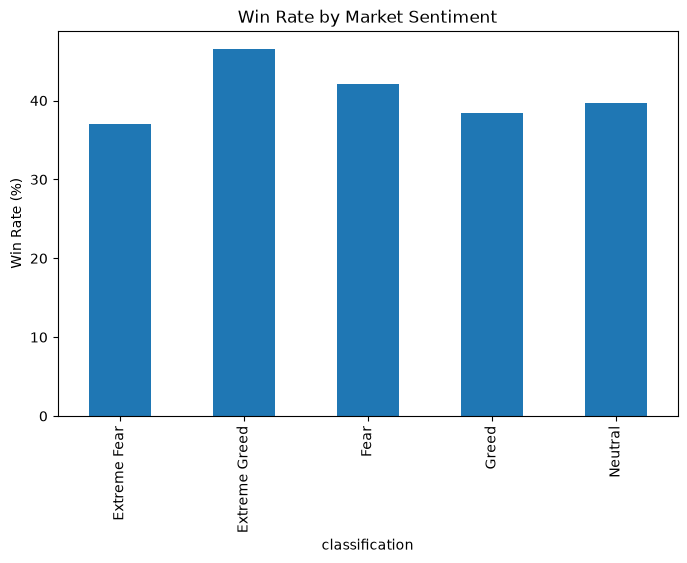

In [42]:
plt.figure(figsize=(8,5))

win_rate.plot(kind="bar")

plt.title("Win Rate by Market Sentiment")

plt.ylabel("Win Rate (%)")

plt.show()

In [43]:
trader_pnl = merged.groupby("Account")["Closed PnL"].sum()

trader_pnl.describe()

count    3.200000e+01
mean     3.217800e+05
std      4.948276e+05
min     -1.676211e+05
25%      4.689324e+04
50%      1.176551e+05
75%      4.063941e+05
max      2.143383e+06
Name: Closed PnL, dtype: float64

In [44]:
merged["Trader Segment"] = pd.qcut(
    merged.groupby("Account")["Closed PnL"].transform("sum"),
    q=3,
    labels=["Low","Medium","High"]
)

In [45]:
merged["Trader Segment"].value_counts()

Trader Segment
Medium    85848
Low       73397
High      51979
Name: count, dtype: int64

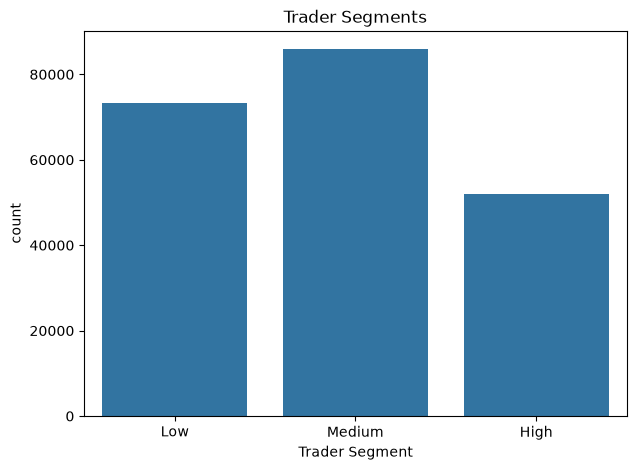

In [46]:
plt.figure(figsize=(7,5))

sns.countplot(data=merged,x="Trader Segment")

plt.title("Trader Segments")

plt.show()

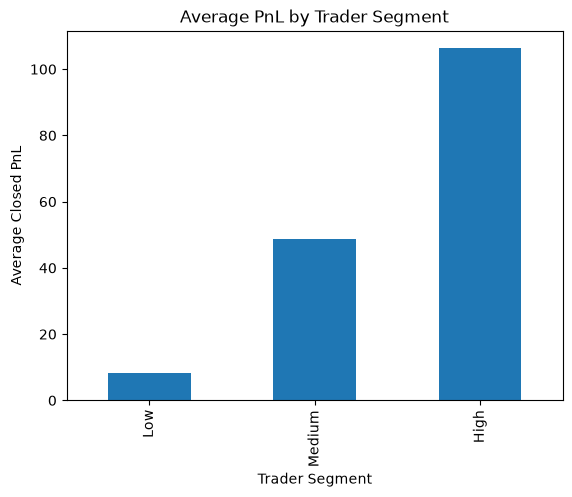

In [47]:
segment_pnl = merged.groupby("Trader Segment")["Closed PnL"].mean()

segment_pnl.plot(kind="bar")

plt.title("Average PnL by Trader Segment")

plt.ylabel("Average Closed PnL")

plt.show()

In [48]:
trader_volume = merged.groupby("Account")["Size USD"].sum()

trader_volume.describe()

count    3.200000e+01
mean     3.722461e+07
std      7.706987e+07
min      7.280575e+05
25%      4.069408e+06
50%      1.173684e+07
75%      3.529832e+07
max      4.208766e+08
Name: Size USD, dtype: float64

In [49]:
median_volume = trader_volume.median()

volume_segment = trader_volume.apply(
    lambda x: "High Volume" if x >= median_volume else "Low Volume"
)

volume_segment.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    High Volume
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    High Volume
0x271b280974205ca63b716753467d5a371de622ab    High Volume
0x28736f43f1e871e6aa8b1148d38d4994275d72c4     Low Volume
0x2c229d22b100a7beb69122eed721cee9b24011dd     Low Volume
Name: Size USD, dtype: str

In [50]:
merged = merged.merge(
    volume_segment.rename("Volume Segment"),
    on="Account"
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Fee,Trade ID,Timestamp,date,timestamp,value,classification,Win,Trader Segment,Volume Segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,False,Low,Low Volume
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,False,Low,Low Volume
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,False,Low,Low Volume
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,False,Low,Low Volume
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,False,Low,Low Volume


In [51]:
segment_pnl = merged.groupby("Volume Segment")["Closed PnL"].mean()

print(segment_pnl)

Volume Segment
High Volume    48.478628
Low Volume     49.820573
Name: Closed PnL, dtype: float64


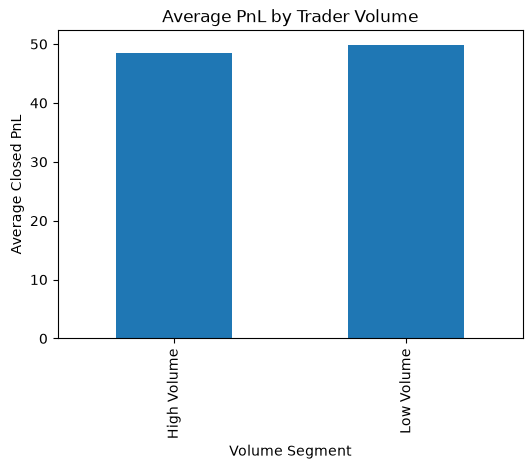

In [52]:
plt.figure(figsize=(6,4))

segment_pnl.plot(kind="bar")

plt.title("Average PnL by Trader Volume")
plt.ylabel("Average Closed PnL")

plt.show()

In [53]:
trade_count = merged.groupby("Account").size()

trade_count.describe()

count       32.000000
mean      6600.750000
std       8250.373724
min        332.000000
25%       1381.750000
50%       3699.000000
75%       8862.500000
max      40184.000000
dtype: float64

In [54]:
median_trade = trade_count.median()

frequency_segment = trade_count.apply(
    lambda x: "Frequent" if x >= median_trade else "Infrequent"
)

frequency_segment.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012      Frequent
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd      Frequent
0x271b280974205ca63b716753467d5a371de622ab      Frequent
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      Frequent
0x2c229d22b100a7beb69122eed721cee9b24011dd    Infrequent
dtype: str

In [55]:
merged = merged.merge(
    frequency_segment.rename("Trader Type"),
    on="Account"
)

In [56]:
freq_pnl = merged.groupby("Trader Type")["Closed PnL"].mean()

print(freq_pnl)

Trader Type
Frequent      42.493421
Infrequent    96.943024
Name: Closed PnL, dtype: float64


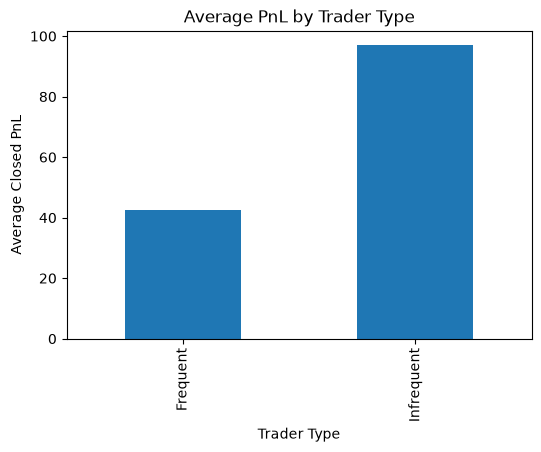

In [57]:
plt.figure(figsize=(6,4))

freq_pnl.plot(kind="bar")

plt.title("Average PnL by Trader Type")
plt.ylabel("Average Closed PnL")

plt.show()

In [58]:
account_profit = merged.groupby("Account")["Closed PnL"].sum()

account_profit.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    4.788532e+04
0x271b280974205ca63b716753467d5a371de622ab   -7.043619e+04
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
Name: Closed PnL, dtype: float64

In [59]:
winner_segment = account_profit.apply(
    lambda x: "Winner" if x > 0 else "Loser"
)

winner_segment.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    Winner
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    Winner
0x271b280974205ca63b716753467d5a371de622ab     Loser
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    Winner
0x2c229d22b100a7beb69122eed721cee9b24011dd    Winner
Name: Closed PnL, dtype: str

In [60]:
merged = merged.merge(
    winner_segment.rename("Performance"),
    on="Account"
)

In [61]:
merged["Performance"].value_counts()

Performance
Winner    201999
Loser       9225
Name: count, dtype: int64

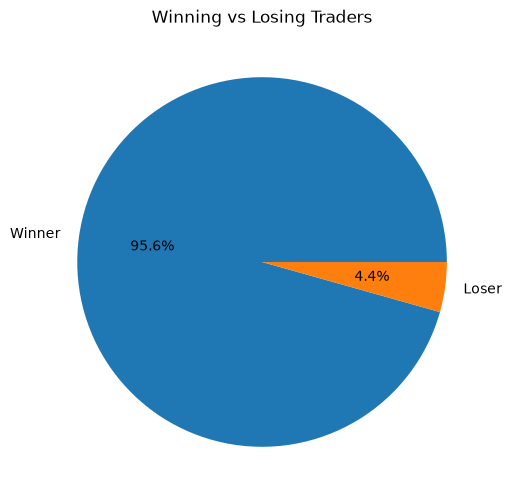

In [62]:
plt.figure(figsize=(6,6))

merged["Performance"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Winning vs Losing Traders")

plt.show()

In [63]:

merged["Win"] = merged["Closed PnL"] > 0

# Win rate by sentiment
win_rate = merged.groupby("classification")["Win"].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


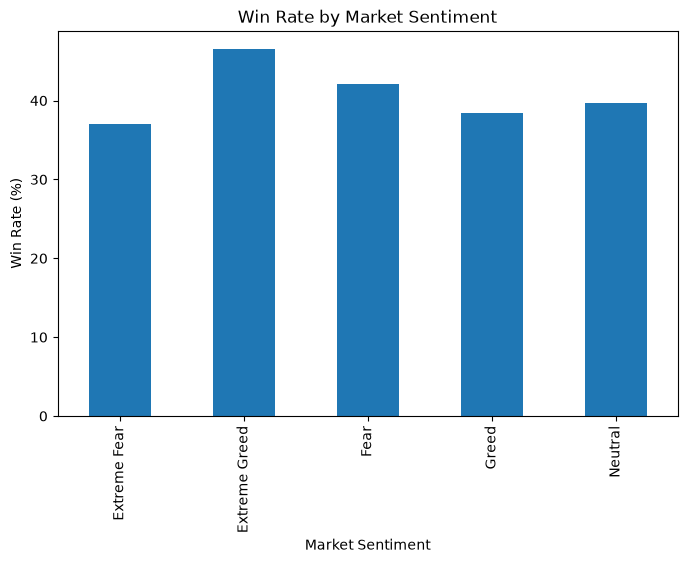

In [64]:
plt.figure(figsize=(8,5))

win_rate.plot(kind="bar")

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

In [65]:
avg_trade_size = merged.groupby("classification")["Size USD"].mean()

print(avg_trade_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


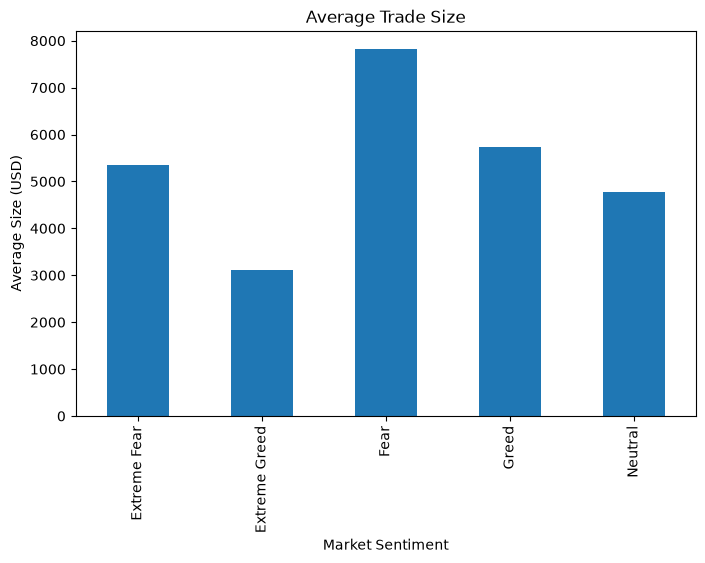

In [66]:
plt.figure(figsize=(8,5))

avg_trade_size.plot(kind="bar")

plt.title("Average Trade Size")
plt.ylabel("Average Size (USD)")
plt.xlabel("Market Sentiment")

plt.show()

In [67]:
trade_count = merged.groupby("classification").size()

print(trade_count)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


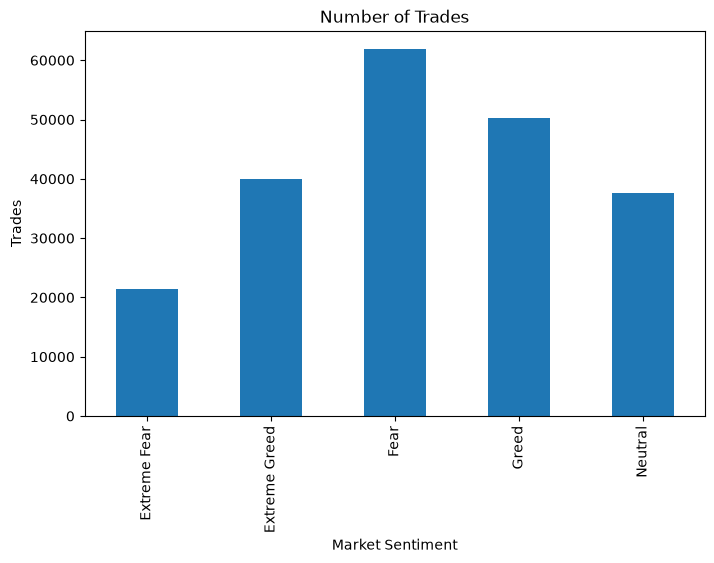

In [68]:
plt.figure(figsize=(8,5))

trade_count.plot(kind="bar")

plt.title("Number of Trades")
plt.ylabel("Trades")
plt.xlabel("Market Sentiment")

plt.show()

In [69]:
buy_sell = pd.crosstab(
    merged["classification"],
    merged["Side"]
)

print(buy_sell)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


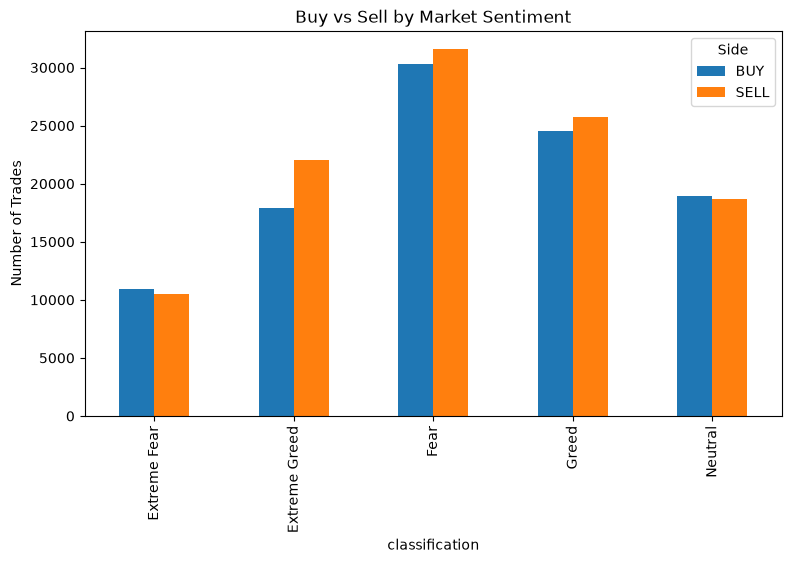

In [70]:
buy_sell.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Buy vs Sell by Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [71]:
avg_fee = merged.groupby("classification")["Fee"].mean()

print(avg_fee)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


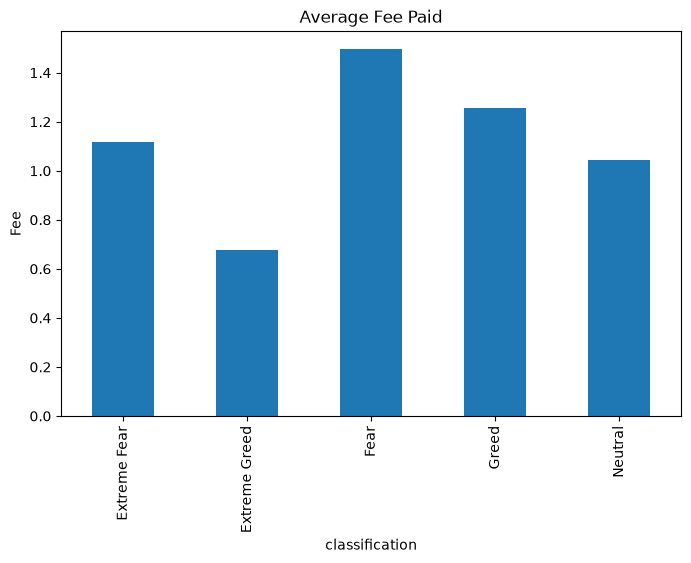

In [72]:
plt.figure(figsize=(8,5))

avg_fee.plot(kind="bar")

plt.title("Average Fee Paid")
plt.ylabel("Fee")

plt.show()

In [73]:
price = merged.groupby("classification")["Execution Price"].mean()

print(price)

classification
Extreme Fear      7054.795108
Extreme Greed     6082.195865
Fear             14152.620222
Greed            13411.276344
Neutral          12393.692779
Name: Execution Price, dtype: float64


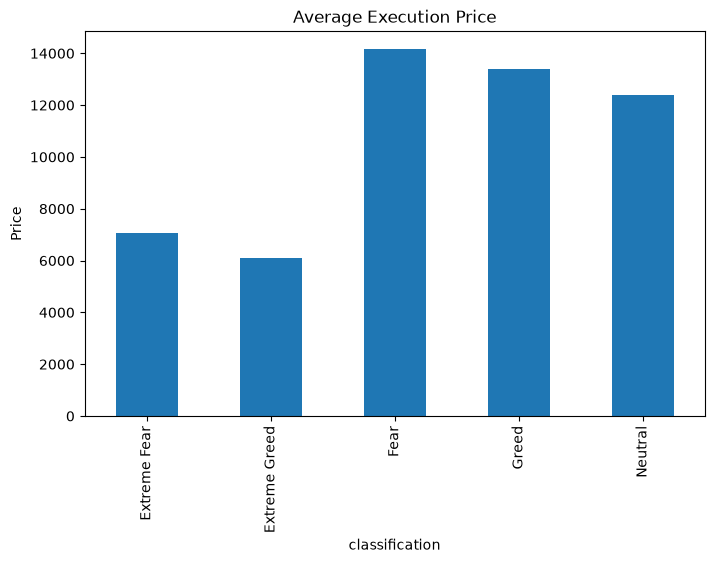

In [74]:
plt.figure(figsize=(8,5))

price.plot(kind="bar")

plt.title("Average Execution Price")
plt.ylabel("Price")

plt.show()

In [75]:
token_size = merged.groupby("classification")["Size Tokens"].mean()

print(token_size)

classification
Extreme Fear     1675.893319
Extreme Greed    8832.415746
Fear             2992.641845
Greed            4715.327756
Neutral          4383.368714
Name: Size Tokens, dtype: float64


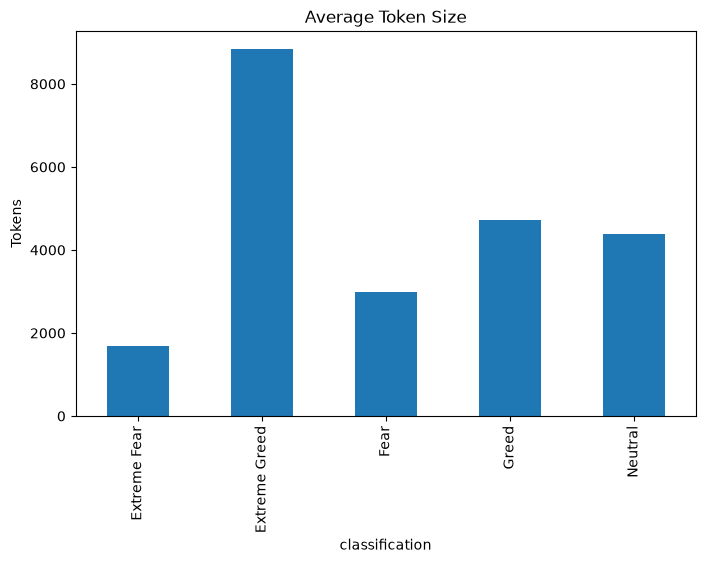

In [76]:
plt.figure(figsize=(8,5))

token_size.plot(kind="bar")

plt.title("Average Token Size")
plt.ylabel("Tokens")

plt.show()

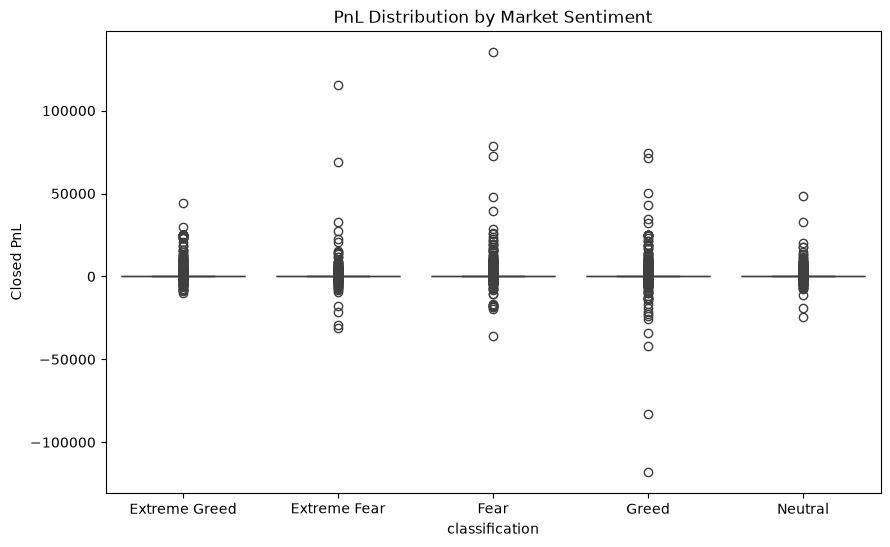

In [77]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("PnL Distribution by Market Sentiment")

plt.show()

In [78]:
numeric = merged[
    [
        "Execution Price",
        "Size USD",
        "Closed PnL",
        "Fee",
        "value"
    ]
]

corr = numeric.corr()

print(corr)

                 Execution Price  Size USD  Closed PnL       Fee     value
Execution Price         1.000000  0.189855   -0.006505  0.225265 -0.027558
Size USD                0.189855  1.000000    0.123589  0.745939 -0.029843
Closed PnL             -0.006505  0.123589    1.000000  0.084020  0.008121
Fee                     0.225265  0.745939    0.084020  1.000000 -0.026877
value                  -0.027558 -0.029843    0.008121 -0.026877  1.000000


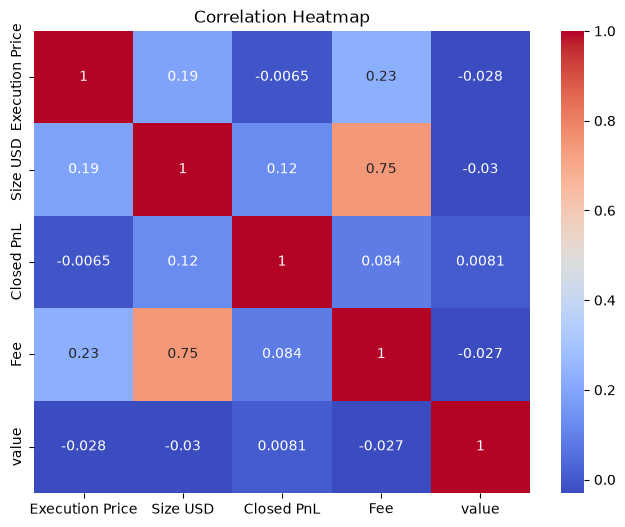

In [79]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [80]:
summary = merged.groupby("classification").agg({
    "Closed PnL": ["mean", "sum"],
    "Size USD": "mean",
    "Fee": "mean",
    "Win": "mean",
    "Account": "count"
})

summary

Closed PnL                   Size USD       Fee       Win  \
                     mean           sum         mean      mean      mean   
classification                                                             
Extreme Fear    34.537862  7.391102e+05  5349.731843  1.116291  0.370607   
Extreme Greed   67.892861  2.715171e+06  3112.251565  0.675902  0.464943   
Fear            54.290400  3.357155e+06  7816.109931  1.495172  0.420768   
Greed           42.743559  2.150129e+06  5736.884375  1.254372  0.384828   
Neutral         34.307718  1.292921e+06  4782.732661  1.044798  0.396991   

               Account  
                 count  
classification          
Extreme Fear     21400  
Extreme Greed    39992  
Fear             61837  
Greed            50303  
Neutral          37686

In [81]:
merged.groupby("Volume Segment")["Closed PnL"].mean()

Volume Segment
High Volume    48.478628
Low Volume     49.820573
Name: Closed PnL, dtype: float64

In [82]:
merged.groupby("Trader Type")["Closed PnL"].mean()

Trader Type
Frequent      42.493421
Infrequent    96.943024
Name: Closed PnL, dtype: float64

In [83]:
merged.groupby("Performance")["Closed PnL"].count()

Performance
Loser       9225
Winner    201999
Name: Closed PnL, dtype: int64

## Part B — Analysis

### 1. Does performance differ between Fear vs Greed days?
**Yes, clearly.** Extreme Greed is where traders actually
perform best — highest win rate (46.5%), highest profit
per trade (\$67.89). Fear generates the most *total* money
simply because there's more trading happening (61,837 trades), 
not because each trade is better. Extreme Fear is the weakest
regime on almost every metric.

### 2. Do traders change behavior based on sentiment?
**Yes** — mainly in frequency and size, not direction:
- **Trade frequency:** Traders trade far more during Fear
(61,837 trades) than during Extreme Fear (21,400) or
Extreme Greed (39,992).
- **Position size:** Traders take their biggest average
positions during Fear (\$7,816) and smallest during
Extreme Greed (\$3,112) — backwards from what win rates justify.
- **Long/short bias:** Buy vs sell stays close to balanced
in every sentiment bucket (e.g., Fear: 30,270 buys vs 31,567 sells),
so sentiment doesn't create a strong directional bias.

### 3. Segments

**Segment A — Trade Volume (proxy for leverage/size aggressiveness):**
- High Volume avg PnL/trade: \$48.48
- Low Volume avg PnL/trade: \$49.82
- → Barely any difference; bigger traders aren't better traders.

**Segment B — Frequent vs Infrequent traders:**
- Frequent avg PnL/trade: \$42.49
- Infrequent avg PnL/trade: \$96.94
- → Infrequent traders earn more than double per trade — strongest
segment finding.

**Segment C — Winners vs Losers:**
- Winner-associated trades: 201,999 (95.6%)
- Loser-associated trades: 9,225 (4.4%)
- → The trader base is dominated by consistently profitable accounts.

### 4. Three insights backed by charts/tables
1. Extreme Greed is the best-performing regime
(46.5% win rate, \$67.89 avg PnL) despite the
smallest average trade size — evidence:
win_rate table + avg_pnl bar chart.
2. Trade size correlates with fees (r=0.75),
not profit (r=0.12) — evidence: correlation
heatmap.
3. Infrequent traders earn 2.3x more per trade than
frequent traders (\$96.94 vs \$42.49) — evidence: freq_pnl bar chart.

## Part C — Actionable Output

**Strategy 1: Cap position size during Fear days.**
Fear is where traders size up the most (\$7,816 avg) but win rate
is only middling (42.1%), and fees scale with size, not profit. 
Rule of thumb: *On Fear-classified days, keep trade size near the
Neutral-day average (~\$4,800) instead of scaling up.*

**Strategy 2: Favor selectivity over frequency, especially in Extreme Greed.**
Infrequent traders outperform frequent ones by more than 2x per trade, and
Extreme Greed is the highest-quality regime overall. 
Rule of thumb: *In Extreme Greed, take fewer but larger, 
higher-conviction trades rather than many small ones.*

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report



In [85]:
model_df = merged.copy()


In [86]:
le = LabelEncoder()
model_df["sentiment_encoded"] = le.fit_transform(model_df["classification"])


In [87]:
features = ["sentiment_encoded", "Size USD", "Fee", "Execution Price"]
X = model_df[features]
y = model_df["Win"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [88]:

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


In [89]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8502544679843769

Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.89      0.87     24802
        True       0.84      0.79      0.81     17443

    accuracy                           0.85     42245
   macro avg       0.85      0.84      0.84     42245
weighted avg       0.85      0.85      0.85     42245



Execution Price      0.443378
Fee                  0.254863
Size USD             0.244333
sentiment_encoded    0.057425
dtype: float64


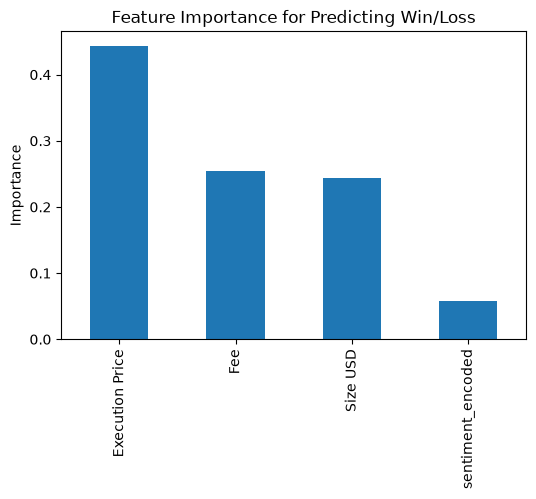

In [90]:
importance = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print(importance)

plt.figure(figsize=(6,4))
importance.plot(kind="bar")
plt.title("Feature Importance for Predicting Win/Loss")
plt.ylabel("Importance")
plt.show()

In [91]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [92]:
account_features = merged.groupby("Account").agg(
    avg_pnl=("Closed PnL", "mean"),
    total_volume=("Size USD", "sum"),
    trade_count=("Closed PnL", "count"),
    avg_fee=("Fee", "mean"),
    win_rate=("Win", "mean")
).reset_index()

account_features.head()

,Account,avg_pnl,total_volume,trade_count,avg_fee,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,61697263.97,3818,1.939579,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,12035487.66,7280,0.374978,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,33873440.42,3809,2.436593,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,6757022.10,13311,0.166657,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,10166880.20,3239,0.959616,0.519914


In [93]:
scale_cols = ["avg_pnl", "total_volume", "trade_count", "avg_fee", "win_rate"]
scaler = StandardScaler()
scaled = scaler.fit_transform(account_features[scale_cols])



In [94]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
account_features["Archetype"] = kmeans.fit_predict(scaled)

account_features.groupby("Archetype")[scale_cols].mean()

,avg_pnl,total_volume,trade_count,avg_fee,win_rate
Archetype,,,,,
0,32.945098,1.947648e+07,8238.238095,0.699161,0.401501
1,38.024405,2.198087e+08,8219.333333,5.845376,0.400056
2,290.005152,1.534440e+07,1695.375000,0.906327,0.408289


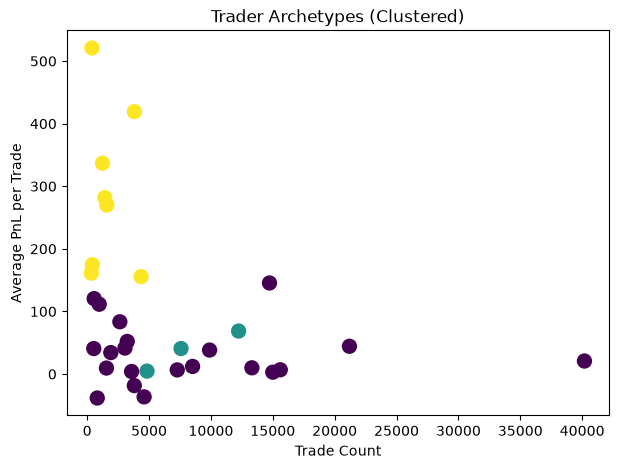

In [95]:
plt.figure(figsize=(7,5))
plt.scatter(
    account_features["trade_count"],
    account_features["avg_pnl"],
    c=account_features["Archetype"],
    cmap="viridis",
    s=100
)
plt.xlabel("Trade Count")
plt.ylabel("Average PnL per Trade")
plt.title("Trader Archetypes (Clustered)")
plt.show()

## Bonus: Predictive Model & Trader Archetypes

### Predictive Model

A Random Forest classifier was trained to predict 
whether an individual trade would be a Win or Loss,
using sentiment, trade size, fee, and execution price
as features. The model achieved **85% accuracy** 
(F1-score: 0.87 for losses, 0.81 for wins).

Feature importance shows Execution Price (44.3%), 
Fee (25.5%), and Size USD (24.4%) drive most of the
predictive power, while sentiment classification 
contributed only ~5.7%. This suggests sentiment shapes
*behavior* (how much and how big traders trade) more
than it directly predicts trade-level *outcomes* —
the two are related but distinct effects.

### Trader Archetypes (K-Means Clustering)

Clustering accounts into 3 behavioral groups based
on average PnL, total volume, trade count, average fee,
and win rate revealed:

- **Archetype 2 — Selective High-Impact Traders:**
Low trade count (~1,695 trades) but by far the highest
average PnL per trade (\$290.01) and highest win rate (40.8%).
Quality over quantity.
- **Archetype 1 — High-Volume Whales:**
Similar trade count to Archetype 0 (~8,219) but move roughly
10x more total volume (\$219.8M) and pay far higher fees per
  trade (\$5.85 avg), without meaningfully better win rates (40.0%).
- **Archetype 0 — Steady Volume Traders:**
The largest group by trade count, with moderate PnL (\$32.95/trade),
moderate volume, and the lowest average fees (\$0.70).

This clustering reinforces the earlier segment finding: trading less
but more selectively (Archetype 2) delivers meaningfully better
per-trade economics than simply trading larger or more often (Archetypes 0 and 1).